In [ ]:
# Raw Data Loading
from pandas import read_csv

column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
                'PTRATIO', 'B', 'LSTAT', 'PRICE']

url = 'https://raw.githubusercontent.com/PinkWink/forML_study_data/main/data/boston_housing.csv'

# delimeter는 seperator 규칙 (r'\s+' 는 데이터 앞에 여러개의 공백이 있다는 의미 (정규표현식))
boston_df = read_csv(url, header=None, delimiter=r"\s+", names=column_names)
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# PRICE의 분포 확인
import plotly.express as px

fig = px.histogram(boston_df, x='PRICE')
fig.show()

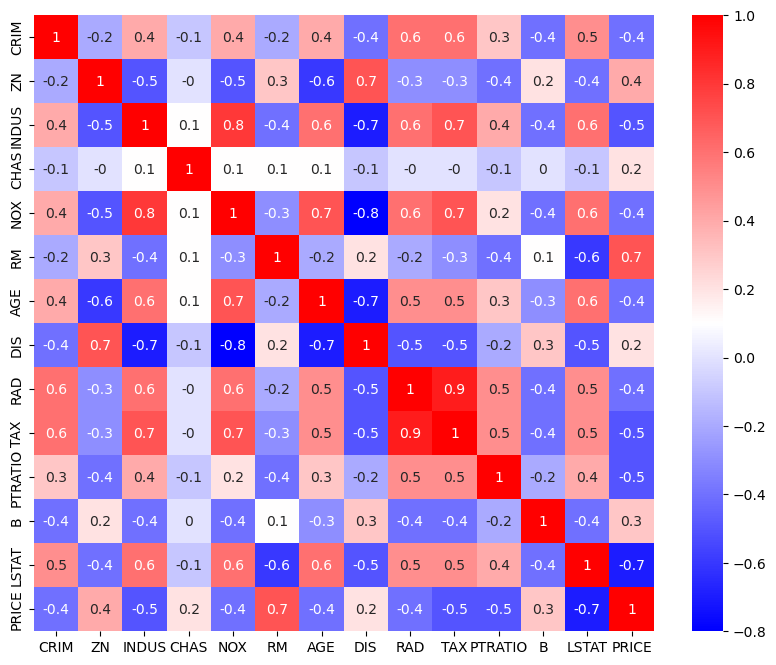

In [ ]:
# 피쳐 간의 상관계수 확인
# RM(방 개수)가 PRICE와 가장 강한 양의 상관관계를 가지고
# LSTAT(하위계층)이 PRICE와 가장 강한 음의 상관관계를 가진다.
import matplotlib.pyplot as plt
import seaborn as sns

corr_mat = boston_df.corr().round(1)

plt.figure(figsize=(10, 8))

sns.heatmap(data=corr_mat,
            annot=True,
            cmap='bwr')

plt.show()

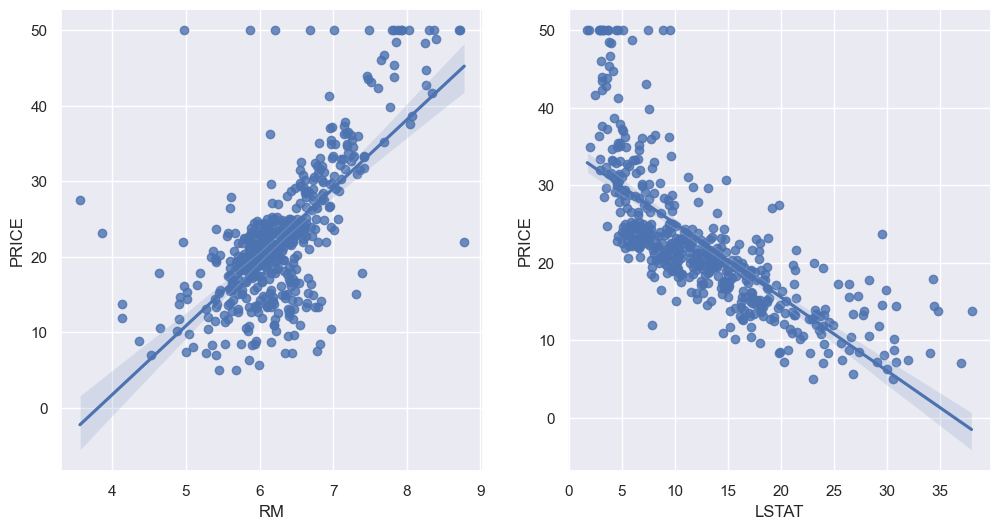

In [ ]:
# PRICE가 높은 몇몇 데이터를 제외하면 어느정도 선형성을 띈다.
sns.set_style('darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

fig, ax = plt.subplots(ncols=2)

sns.regplot(data=boston_df,
            x='RM',
            y='PRICE',
            ax=ax[0])
sns.regplot(data=boston_df,
            x='LSTAT',
            y='PRICE',
            ax=ax[1])

plt.show()

In [9]:
# 모든 피쳐를 사용하여 모델 생성
from sklearn.model_selection import train_test_split

x = boston_df.drop('PRICE', axis=1)
y = boston_df['PRICE']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

In [10]:
# 모델 학습
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
# RMSE 계산 (현재 모델의 성능을 판단할 순 없음)
import numpy as np
from sklearn.metrics import mean_squared_error

pred_train = lr.predict(x_train)
pred_test = lr.predict(x_test)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f'RMSE of Train Data: {rmse_train}')
print(f'RMSE of Test Data: {rmse_test}')

RMSE of Train Data: 4.642806069019824
RMSE of Test Data: 4.931352584146716


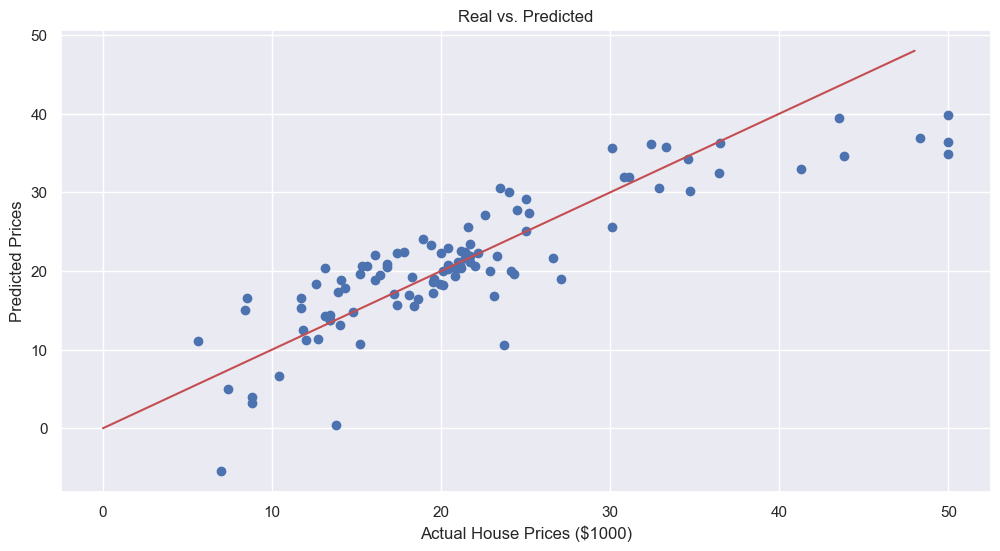

In [14]:
# 실제값과 예측값 비교 시각화
plt.figure(figsize=(12, 6))

plt.scatter(y_test, pred_test)
plt.plot([0, 48], [0, 48], 'r')

plt.title('Real vs. Predicted')
plt.xlabel('Actual House Prices ($1000)')
plt.ylabel('Predicted Prices')

plt.show()

In [27]:
# 과연 LSTAT 피쳐를 포함해도 될까?
# 만약 주변에 하위 계층 사람들이 많이 살아서 집값이 싼 것인지,
# 집값이 싸기 때문에 주변에 하위 계층 사람들이 많이 사는 건지 인과관계가 모호함
x = boston_df.drop(['PRICE', 'LSTAT'], axis=1)
y = boston_df['PRICE']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [28]:
# LSTAT 피쳐를 포함하지 않았을 때 포함하였을 때보다 오차가 커짐
pred_train = lr.predict(x_train)
pred_test = lr.predict(x_test)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f'RMSE of Train Data: {rmse_train}')
print(f'RMSE of Test Data: {rmse_test}')

RMSE of Train Data: 5.165137874244864
RMSE of Test Data: 5.2955950325971655


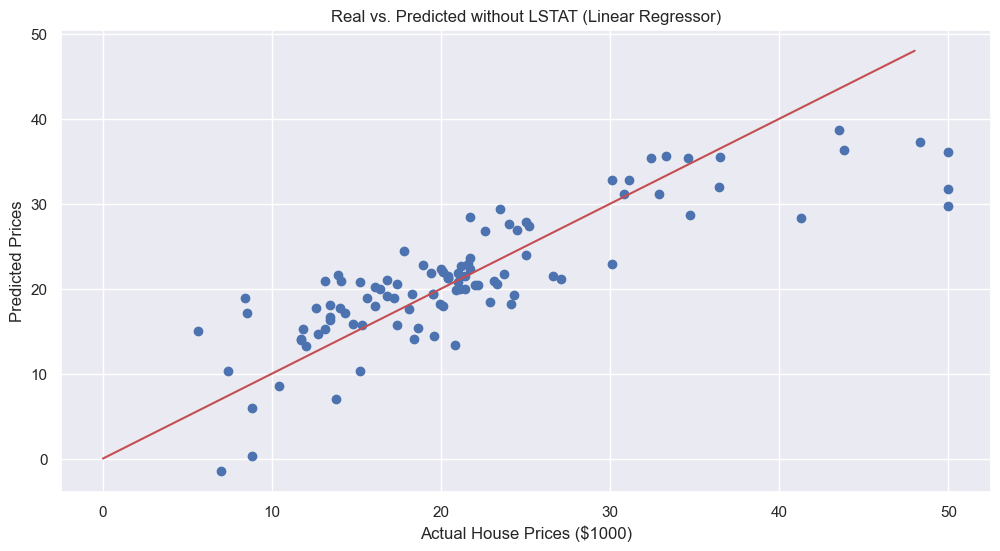

In [30]:
# 실제값과 예측값 비교 시각화
plt.figure(figsize=(12, 6))

plt.scatter(y_test, pred_test)
plt.plot([0, 48], [0, 48], 'r')

plt.title('Real vs. Predicted without LSTAT (Linear Regressor)')
plt.xlabel('Actual House Prices ($1000)')
plt.ylabel('Predicted Prices')

plt.show()

In [37]:
# 이번엔 선형 회귀 모델이 아닌 비선형 회귀 모델 (Decision Tree Regressor)
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(max_depth=2, random_state=13)
dtr.fit(x_train, y_train)

pred_test = dtr.predict(x_test)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f'RMSE of Test Data: {rmse_test}')

RMSE of Test Data: 5.698005991702834


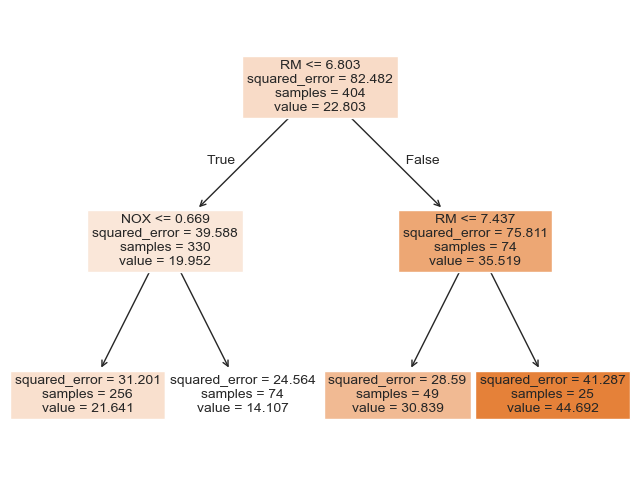

In [32]:
# RM이 회귀에 가장 중요한 피쳐인 것을 확인할 수 있음.
from sklearn import tree

fig = plt.figure(figsize=(8, 6))
_ = tree.plot_tree(dtr,
                   feature_names=column_names,
                   filled=True)

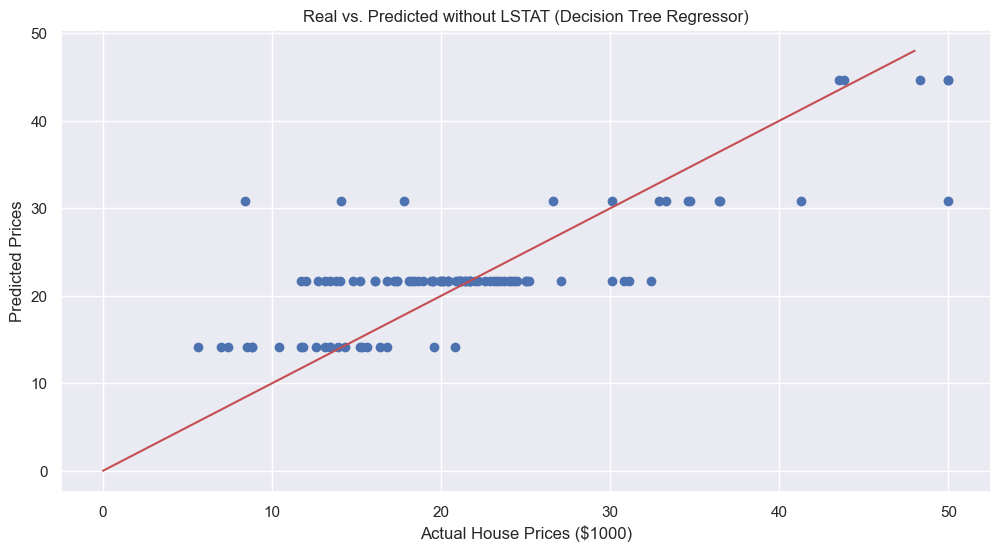

In [38]:
# 실제값과 예측값 비교 시각화
plt.figure(figsize=(12, 6))

plt.scatter(y_test, pred_test)
plt.plot([0, 48], [0, 48], 'r')

plt.title('Real vs. Predicted without LSTAT (Decision Tree Regressor)')
plt.xlabel('Actual House Prices ($1000)')
plt.ylabel('Predicted Prices')

plt.show()